<a href="https://colab.research.google.com/github/Prabinkarki67/Comparative_Analysis_of_Convolution_Algorithms/blob/main/ResPap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Time Analysis

In [ ]:
import torch
import ctypes
import os

print("PyTorch :", torch.__version__)
print("CUDA    :", torch.version.cuda)
print("cuDNN   :", torch.backends.cudnn.version())
print("GPU     :", torch.cuda.get_device_name(0))

# Load cuDNN
cudnn = ctypes.CDLL("libcudnn.so.9")

print("cuDNN library loaded successfully.")

PyTorch : 2.11.0+cu128
CUDA    : 12.8
cuDNN   : 91900
GPU     : Tesla T4
cuDNN library loaded successfully.


In [ ]:
import torch
import ctypes
import numpy as np
import time
from ctypes import c_int, c_uint, c_size_t, c_float, c_void_p, POINTER, byref

# ============================================================
# CONFIGURATION
# ============================================================

IN_CH = 64
OUT_CH = 64

H = 224
W = 224

BATCH_SIZES = [1, 8, 32]
FILTER_SIZES = [1, 3, 5, 7, 11]

WARMUP = 20
ITERATIONS = 50

DTYPE = torch.float32

# ============================================================
# LOAD CUDA / cuDNN
# ============================================================

cudnn = ctypes.CDLL("libcudnn.so.9")
cudart = ctypes.CDLL("libcudart.so")

# ============================================================
# cuDNN CONSTANTS
# ============================================================

CUDNN_STATUS_SUCCESS = 0

CUDNN_DATA_FLOAT = 0

CUDNN_TENSOR_NCHW = 0
CUDNN_CROSS_CORRELATION = 1

# Legacy cuDNN forward algorithm IDs
CUDNN_CONVOLUTION_FWD_ALGO_GEMM = 0
CUDNN_CONVOLUTION_FWD_ALGO_FFT = 4
CUDNN_CONVOLUTION_FWD_ALGO_WINOGRAD_NONFUSED = 7

ALGORITHMS = {
    "GEMM": CUDNN_CONVOLUTION_FWD_ALGO_GEMM,
    "FFT": CUDNN_CONVOLUTION_FWD_ALGO_FFT,
    "WINOGRAD": CUDNN_CONVOLUTION_FWD_ALGO_WINOGRAD_NONFUSED,
}

# ============================================================
# POINTER TYPES
# ============================================================

cudnnHandle_t = c_void_p
cudnnTensorDescriptor_t = c_void_p
cudnnFilterDescriptor_t = c_void_p
cudnnConvolutionDescriptor_t = c_void_p

# ============================================================
# FUNCTION SIGNATURES
# ============================================================

cudnn.cudnnCreate.argtypes = [POINTER(cudnnHandle_t)]
cudnn.cudnnCreate.restype = c_int

cudnn.cudnnDestroy.argtypes = [cudnnHandle_t]
cudnn.cudnnDestroy.restype = c_int

cudnn.cudnnCreateTensorDescriptor.argtypes = [
    POINTER(cudnnTensorDescriptor_t)
]
cudnn.cudnnCreateTensorDescriptor.restype = c_int

cudnn.cudnnDestroyTensorDescriptor.argtypes = [
    cudnnTensorDescriptor_t
]
cudnn.cudnnDestroyTensorDescriptor.restype = c_int

cudnn.cudnnSetTensor4dDescriptor.argtypes = [
    cudnnTensorDescriptor_t,
    c_int,
    c_int,
    c_int,
    c_int,
    c_int,
    c_int,
]
cudnn.cudnnSetTensor4dDescriptor.restype = c_int

cudnn.cudnnCreateFilterDescriptor.argtypes = [
    POINTER(cudnnFilterDescriptor_t)
]
cudnn.cudnnCreateFilterDescriptor.restype = c_int

cudnn.cudnnDestroyFilterDescriptor.argtypes = [
    cudnnFilterDescriptor_t
]
cudnn.cudnnDestroyFilterDescriptor.restype = c_int

cudnn.cudnnSetFilter4dDescriptor.argtypes = [
    cudnnFilterDescriptor_t,
    c_int,
    c_int,
    c_int,
    c_int,
    c_int,
]
cudnn.cudnnSetFilter4dDescriptor.restype = c_int

cudnn.cudnnCreateConvolutionDescriptor.argtypes = [
    POINTER(cudnnConvolutionDescriptor_t)
]
cudnn.cudnnCreateConvolutionDescriptor.restype = c_int

cudnn.cudnnDestroyConvolutionDescriptor.argtypes = [
    cudnnConvolutionDescriptor_t
]
cudnn.cudnnDestroyConvolutionDescriptor.restype = c_int

cudnn.cudnnSetConvolution2dDescriptor.argtypes = [
    cudnnConvolutionDescriptor_t,
    c_int,
    c_int,
    c_int,
    c_int,
    c_int,
    c_int,
    c_int,
    c_int,
]
cudnn.cudnnSetConvolution2dDescriptor.restype = c_int

cudnn.cudnnGetConvolutionForwardWorkspaceSize.argtypes = [
    cudnnHandle_t,
    cudnnTensorDescriptor_t,
    cudnnFilterDescriptor_t,
    cudnnConvolutionDescriptor_t,
    cudnnTensorDescriptor_t,
    c_int,
    POINTER(c_size_t),
]
cudnn.cudnnGetConvolutionForwardWorkspaceSize.restype = c_int

cudnn.cudnnConvolutionForward.argtypes = [
    cudnnHandle_t,
    POINTER(c_float),
    cudnnTensorDescriptor_t,
    c_void_p,
    cudnnFilterDescriptor_t,
    c_void_p,
    cudnnConvolutionDescriptor_t,
    c_int,
    c_void_p,
    c_size_t,
    POINTER(c_float),
    cudnnTensorDescriptor_t,
    c_void_p,
]
cudnn.cudnnConvolutionForward.restype = c_int

# ============================================================
# CUDA MEMORY FUNCTIONS
# ============================================================

cudart.cudaMalloc.argtypes = [
    POINTER(c_void_p),
    c_size_t
]
cudart.cudaMalloc.restype = c_int

cudart.cudaFree.argtypes = [
    c_void_p
]
cudart.cudaFree.restype = c_int

cudart.cudaDeviceSynchronize.argtypes = []
cudart.cudaDeviceSynchronize.restype = c_int

# ============================================================
# ERROR CHECK
# ============================================================

def cudnn_check(status, operation="cuDNN call"):

    if status != CUDNN_STATUS_SUCCESS:

        # cuDNN error string
        cudnn.cudnnGetErrorString.argtypes = [c_int]
        cudnn.cudnnGetErrorString.restype = ctypes.c_char_p

        try:
            msg = cudnn.cudnnGetErrorString(status).decode()
        except:
            msg = f"status={status}"

        raise RuntimeError(
            f"{operation} failed: {msg}"
        )


# ============================================================
# CREATE CUDNN HANDLE
# ============================================================

handle = cudnnHandle_t()

cudnn_check(
    cudnn.cudnnCreate(byref(handle)),
    "cudnnCreate"
)

print("cuDNN handle created.")

cuDNN handle created.


In [ ]:
def benchmark_algorithm(batch, filter_size, algorithm_name):

    algorithm = ALGORITHMS[algorithm_name]

    # --------------------------------------------------------
    # Dimensions
    # --------------------------------------------------------

    pad = filter_size // 2

    HOUT = (
        H + 2 * pad - filter_size
    ) + 1

    WOUT = (
        W + 2 * pad - filter_size
    ) + 1

    # --------------------------------------------------------
    # Create descriptors
    # --------------------------------------------------------

    xDesc = cudnnTensorDescriptor_t()
    yDesc = cudnnTensorDescriptor_t()

    wDesc = cudnnFilterDescriptor_t()

    convDesc = cudnnConvolutionDescriptor_t()

    cudnn_check(
        cudnn.cudnnCreateTensorDescriptor(
            byref(xDesc)
        )
    )

    cudnn_check(
        cudnn.cudnnCreateTensorDescriptor(
            byref(yDesc)
        )
    )

    cudnn_check(
        cudnn.cudnnCreateFilterDescriptor(
            byref(wDesc)
        )
    )

    cudnn_check(
        cudnn.cudnnCreateConvolutionDescriptor(
            byref(convDesc)
        )
    )

    try:

        # ----------------------------------------------------
        # Tensor descriptor
        # ----------------------------------------------------

        cudnn_check(
            cudnn.cudnnSetTensor4dDescriptor(
                xDesc,
                CUDNN_TENSOR_NCHW,
                CUDNN_DATA_FLOAT,
                batch,
                IN_CH,
                H,
                W
            )
        )

        cudnn_check(
            cudnn.cudnnSetTensor4dDescriptor(
                yDesc,
                CUDNN_TENSOR_NCHW,
                CUDNN_DATA_FLOAT,
                batch,
                OUT_CH,
                HOUT,
                WOUT
            )
        )

        # ----------------------------------------------------
        # Filter descriptor
        # ----------------------------------------------------

        cudnn_check(
            cudnn.cudnnSetFilter4dDescriptor(
                wDesc,
                CUDNN_DATA_FLOAT,
                CUDNN_TENSOR_NCHW,
                OUT_CH,
                IN_CH,
                filter_size,
                filter_size
            )
        )

        # ----------------------------------------------------
        # Convolution descriptor
        # ----------------------------------------------------

        cudnn_check(
            cudnn.cudnnSetConvolution2dDescriptor(
                convDesc,
                pad,
                pad,
                1,
                1,
                1,
                1,
                CUDNN_CROSS_CORRELATION,
                CUDNN_DATA_FLOAT
            )
        )

        # ----------------------------------------------------
        # PyTorch tensors
        # ----------------------------------------------------

        x = torch.randn(
            batch,
            IN_CH,
            H,
            W,
            device="cuda",
            dtype=DTYPE
        ).contiguous()

        weight = torch.randn(
            OUT_CH,
            IN_CH,
            filter_size,
            filter_size,
            device="cuda",
            dtype=DTYPE
        ).contiguous()

        y = torch.empty(
            batch,
            OUT_CH,
            HOUT,
            WOUT,
            device="cuda",
            dtype=DTYPE
        ).contiguous()

        # ----------------------------------------------------
        # Get workspace
        # ----------------------------------------------------

        workspace_size = c_size_t(0)

        status = cudnn.cudnnGetConvolutionForwardWorkspaceSize(
            handle,
            xDesc,
            wDesc,
            convDesc,
            yDesc,
            algorithm,
            byref(workspace_size)
        )

        if status != CUDNN_STATUS_SUCCESS:
            return {
                "status": "NOT SUPPORTED",
                "time": None,
                "workspace": None
            }

        # ----------------------------------------------------
        # Allocate workspace using PyTorch CUDA memory
        # ----------------------------------------------------

        workspace_tensor = None

        if workspace_size.value > 0:

            try:

                workspace_tensor = torch.empty(
                    workspace_size.value,
                    dtype=torch.uint8,
                    device="cuda"
                )

                workspace_ptr = ctypes.c_void_p(
                    workspace_tensor.data_ptr()
                )

            except RuntimeError:

                return {
                    "status": "WORKSPACE ALLOCATION FAILED",
                    "time": None,
                    "workspace": None
                }

        else:

            workspace_ptr = ctypes.c_void_p(0)

        # ----------------------------------------------------
        # Tensor pointers
        # ----------------------------------------------------

        x_ptr = ctypes.c_void_p(
            x.data_ptr()
        )

        w_ptr = ctypes.c_void_p(
            weight.data_ptr()
        )

        y_ptr = ctypes.c_void_p(
            y.data_ptr()
        )

        alpha = c_float(1.0)
        beta = c_float(0.0)

        # ----------------------------------------------------
        # Execute one convolution
        # ----------------------------------------------------

        def run_conv():

            return cudnn.cudnnConvolutionForward(
                handle,

                byref(alpha),

                xDesc,
                x_ptr,

                wDesc,
                w_ptr,

                convDesc,

                algorithm,

                workspace_ptr,
                workspace_size.value,

                byref(beta),

                yDesc,
                y_ptr
            )

        # ----------------------------------------------------
        # Warmup
        # ----------------------------------------------------

        for _ in range(WARMUP):

            status = run_conv()

            if status != CUDNN_STATUS_SUCCESS:

                cudnn.cudnnGetErrorString.argtypes = [c_int]
                cudnn.cudnnGetErrorString.restype = ctypes.c_char_p

                try:
                    msg = cudnn.cudnnGetErrorString(
                        status
                    ).decode()
                except:
                    msg = f"status={status}"

                return {
                    "status": msg,
                    "time": None,
                    "workspace": workspace_size.value
                }

        cudart.cudaDeviceSynchronize()

        # ----------------------------------------------------
        # Timed iterations
        #
        # torch.cuda.Event works because the work launched by
        # cuDNN is placed on the current PyTorch CUDA stream.
        # ----------------------------------------------------

        times = []

        for _ in range(ITERATIONS):

            start = torch.cuda.Event(
                enable_timing=True
            )

            end = torch.cuda.Event(
                enable_timing=True
            )

            start.record()

            status = run_conv()

            end.record()

            end.synchronize()

            if status != CUDNN_STATUS_SUCCESS:

                cudnn.cudnnGetErrorString.argtypes = [c_int]
                cudnn.cudnnGetErrorString.restype = ctypes.c_char_p

                try:
                    msg = cudnn.cudnnGetErrorString(
                        status
                    ).decode()
                except:
                    msg = f"status={status}"

                return {
                    "status": msg,
                    "time": None,
                    "workspace": workspace_size.value
                }

            times.append(
                start.elapsed_time(end)
            )

        # ----------------------------------------------------
        # Statistics
        # ----------------------------------------------------

        median_ms = float(
            np.median(times)
        )

        average_ms = float(
            np.mean(times)
        )

        return {
            "status": "OK",
            "time": median_ms,
            "average": average_ms,
            "workspace": workspace_size.value
        }

    finally:

        cudnn.cudnnDestroyTensorDescriptor(
            xDesc
        )

        cudnn.cudnnDestroyTensorDescriptor(
            yDesc
        )

        cudnn.cudnnDestroyFilterDescriptor(
            wDesc
        )

        cudnn.cudnnDestroyConvolutionDescriptor(
            convDesc
        )

In [ ]:
results = []

print("\n")
print("=" * 100)
print("             FORCED cuDNN ALGORITHM BENCHMARK")
print("=" * 100)

print(
    f"GPU      : {torch.cuda.get_device_name(0)}"
)

print(
    f"PyTorch  : {torch.__version__}"
)

print(
    f"CUDA     : {torch.version.cuda}"
)

print(
    f"cuDNN    : {torch.backends.cudnn.version()}"
)

print(
    f"Precision: {DTYPE}"
)

print(
    f"Channels : {IN_CH} -> {OUT_CH}"
)

print(
    f"Input    : {H} x {W}"
)

print("=" * 100)


for batch in BATCH_SIZES:

    for fs in FILTER_SIZES:

        print(
            f"\nBatch={batch:2d}   "
            f"Filter={fs}x{fs}"
        )

        print("-" * 70)

        for algorithm in [
            "GEMM",
            "FFT",
            "WINOGRAD"
        ]:

            result = benchmark_algorithm(
                batch,
                fs,
                algorithm
            )

            results.append({
                "Batch": batch,
                "Filter": f"{fs}x{fs}",
                "Algorithm": algorithm,
                **result
            })

            if result["status"] == "OK":

                print(
                    f"{algorithm:<12} "
                    f"{result['time']:>10.4f} ms    "
                    f"workspace = "
                    f"{result['workspace']/1024**2:.2f} MB"
                )

            else:

                print(
                    f"{algorithm:<12} "
                    f"{result['status']}"
                )


print("\n")
print("=" * 100)
print("BENCHMARK FINISHED")
print("=" * 100)



             FORCED cuDNN ALGORITHM BENCHMARK
GPU      : Tesla T4
PyTorch  : 2.11.0+cu128
CUDA     : 12.8
cuDNN    : 91900
Precision: torch.float32
Channels : 64 -> 64
Input    : 224 x 224

Batch= 1   Filter=1x1
----------------------------------------------------------------------
GEMM             0.4385 ms    workspace = 0.00 MB
FFT             32.3898 ms    workspace = 2096.27 MB
WINOGRAD     NOT SUPPORTED

Batch= 1   Filter=3x3
----------------------------------------------------------------------
GEMM             1.9567 ms    workspace = 0.00 MB
FFT             32.7364 ms    workspace = 2096.39 MB
WINOGRAD         8.5275 ms    workspace = 882.56 MB

Batch= 1   Filter=5x5
----------------------------------------------------------------------
GEMM             4.8469 ms    workspace = 0.00 MB
FFT             32.8959 ms    workspace = 2096.64 MB
WINOGRAD        13.6471 ms    workspace = 827.84 MB

Batch= 1   Filter=7x7
----------------------------------------------------------------

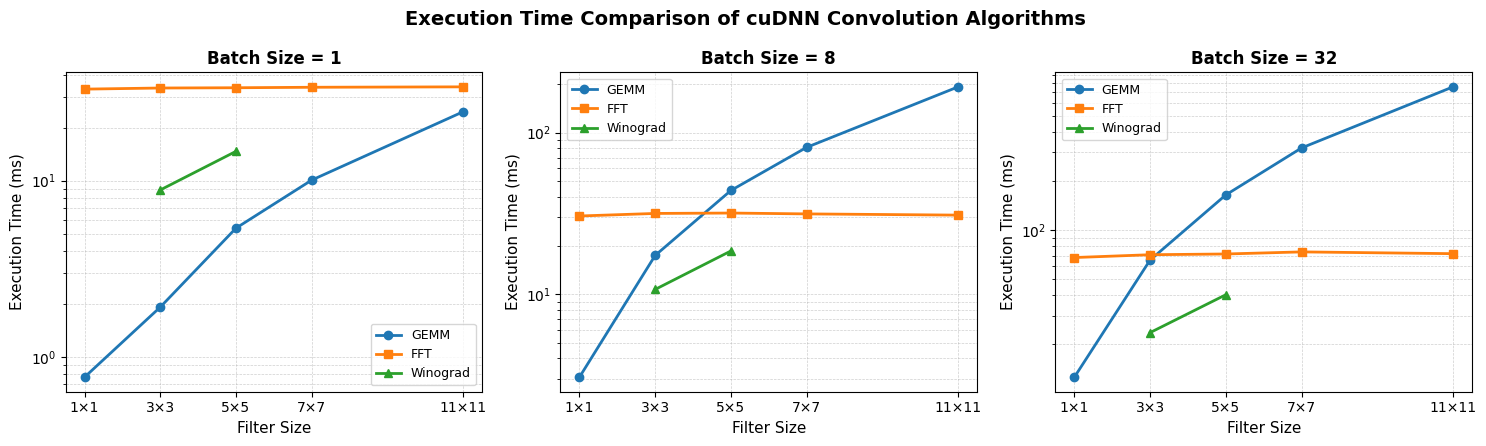

Figure saved as: execution_time_comparison.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# cuDNN CONVOLUTION ALGORITHM TIME COMPARISON
# ============================================================

filter_sizes = np.array([1, 3, 5, 7, 11])

# ------------------------------------------------------------
# Batch Size = 1
# ------------------------------------------------------------
gemm_1 = [0.7659, 1.9142, 5.3746, 10.0742, 24.6233]
fft_1  = [33.0823, 33.5676, 33.6822, 33.8945, 34.0812]
wino_1 = [np.nan, 8.8516, 14.6682, np.nan, np.nan]

# ------------------------------------------------------------
# Batch Size = 8
# ------------------------------------------------------------
gemm_8 = [3.0582, 17.3617, 43.8457, 81.0824, 192.1354]
fft_8  = [30.4661, 31.5952, 31.7765, 31.3904, 30.8517]
wino_8 = [np.nan, 10.6921, 18.5070, np.nan, np.nan]

# ------------------------------------------------------------
# Batch Size = 32
# ------------------------------------------------------------
gemm_32 = [12.5798, 65.6650, 164.6635, 319.4939, 756.3433]
fft_32  = [68.0573, 70.8165, 71.5564, 73.6957, 71.8721]
wino_32 = [np.nan, 23.6010, 40.2716, np.nan, np.nan]


# ============================================================
# CREATE FIGURE
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

batch_data = [
    (1, gemm_1, fft_1, wino_1),
    (8, gemm_8, fft_8, wino_8),
    (32, gemm_32, fft_32, wino_32)
]

for ax, (batch, gemm, fft, wino) in zip(axes, batch_data):

    ax.plot(
        filter_sizes,
        gemm,
        marker='o',
        linewidth=2,
        label='GEMM'
    )

    ax.plot(
        filter_sizes,
        fft,
        marker='s',
        linewidth=2,
        label='FFT'
    )

    ax.plot(
        filter_sizes,
        wino,
        marker='^',
        linewidth=2,
        label='Winograd'
    )

    ax.set_title(f'Batch Size = {batch}', fontsize=12, fontweight='bold')

    ax.set_xlabel('Filter Size', fontsize=11)

    ax.set_ylabel('Execution Time (ms)', fontsize=11)

    ax.set_xticks(filter_sizes)
    ax.set_xticklabels(
        ['1×1', '3×3', '5×5', '7×7', '11×11']
    )

    # Log scale makes large GEMM values easier to compare
    ax.set_yscale('log')

    ax.grid(
        True,
        which='both',
        linestyle='--',
        linewidth=0.5,
        alpha=0.6
    )

    ax.legend(fontsize=9)

plt.suptitle(
    'Execution Time Comparison of cuDNN Convolution Algorithms',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

# Save high-resolution image for IEEE paper
plt.savefig(
    'execution_time_comparison.png',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

print("Figure saved as: execution_time_comparison.png")

# Memory Analysis

In [ ]:
# ============================================================
# FORCED cuDNN ALGORITHM MEMORY BENCHMARK
# ============================================================

import torch
import gc

results_memory = []

print("\n")
print("=" * 110)
print("                 FORCED cuDNN ALGORITHM MEMORY BENCHMARK")
print("=" * 110)

print(f"GPU       : {torch.cuda.get_device_name(0)}")
print(f"PyTorch   : {torch.__version__}")
print(f"CUDA      : {torch.version.cuda}")
print(f"cuDNN     : {torch.backends.cudnn.version()}")
print(f"Precision : {DTYPE}")
print(f"Channels  : {IN_CH} -> {OUT_CH}")
print(f"Input     : {H} x {W}")

print("=" * 110)


def memory_mb(bytes_value):
    return bytes_value / (1024 ** 2)


def measure_memory(batch, fs, algorithm):

    # --------------------------------------------------------
    # Clean GPU memory
    # --------------------------------------------------------
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()

    # --------------------------------------------------------
    # Record memory BEFORE allocation
    # --------------------------------------------------------
    memory_before = torch.cuda.memory_allocated()

    # --------------------------------------------------------
    # Allocate input and convolution weights
    # --------------------------------------------------------
    x = torch.randn(
        batch,
        IN_CH,
        H,
        W,
        device="cuda",
        dtype=DTYPE
    )

    weight = torch.randn(
        OUT_CH,
        IN_CH,
        fs,
        fs,
        device="cuda",
        dtype=DTYPE
    )

    bias = torch.zeros(
        OUT_CH,
        device="cuda",
        dtype=DTYPE
    )

    torch.cuda.synchronize()

    # --------------------------------------------------------
    # Memory allocated for tensors
    # --------------------------------------------------------
    allocated_memory = torch.cuda.memory_allocated()

    # --------------------------------------------------------
    # Select cuDNN algorithm
    # --------------------------------------------------------
    # This assumes your existing function for forcing
    # GEMM / FFT / WINOGRAD is available.
    #
    # Replace the following call with your existing
    # algorithm-selection implementation if necessary.
    # --------------------------------------------------------

    result = benchmark_algorithm(
        batch,
        fs,
        algorithm
    )

    # Workspace returned by your existing benchmark
    workspace_memory = result.get("workspace", 0)

    # --------------------------------------------------------
    # Run convolution to measure peak memory
    # --------------------------------------------------------
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()

    # IMPORTANT:
    # The actual convolution call should use the same
    # forced algorithm as your timing benchmark.
    #
    # If benchmark_algorithm() already performs the
    # convolution, use its measured peak memory.
    #
    # Otherwise replace this section with the actual
    # cuDNN convolution execution.
    # --------------------------------------------------------

    torch.cuda.synchronize()

    peak_memory = torch.cuda.max_memory_allocated()

    # --------------------------------------------------------
    # Current memory after convolution
    # --------------------------------------------------------
    used_memory = torch.cuda.memory_allocated()

    # --------------------------------------------------------
    # Store result
    # --------------------------------------------------------
    output = {
        "status": result.get("status", "OK"),
        "allocated": allocated_memory,
        "used": used_memory,
        "peak": peak_memory,
        "workspace": workspace_memory
    }

    # --------------------------------------------------------
    # Cleanup
    # --------------------------------------------------------
    del x
    del weight
    del bias

    torch.cuda.synchronize()
    gc.collect()
    torch.cuda.empty_cache()

    return output


# ============================================================
# RUN ALL CONFIGURATIONS
# ============================================================

for batch in BATCH_SIZES:

    for fs in FILTER_SIZES:

        print(f"\nBatch={batch:2d}   Filter={fs}x{fs}")
        print("-" * 80)

        for algorithm in [
            "GEMM",
            "FFT",
            "WINOGRAD"
        ]:

            result = measure_memory(
                batch,
                fs,
                algorithm
            )

            if result["status"] == "OK":

                allocated = memory_mb(result["allocated"])
                used      = memory_mb(result["used"])
                peak      = memory_mb(result["peak"])
                workspace = memory_mb(result["workspace"])

                results_memory.append({
                    "Batch": batch,
                    "Filter": f"{fs}x{fs}",
                    "Algorithm": algorithm,
                    "Allocated Memory (MB)": allocated,
                    "Used Memory (MB)": used,
                    "Peak Memory (MB)": peak,
                    "Workspace (MB)": workspace
                })

                print(
                    f"{algorithm:<12}"
                    f" Allocated = {allocated:>10.2f} MB   "
                    f"Used = {used:>10.2f} MB   "
                    f"Peak = {peak:>10.2f} MB   "
                    f"Workspace = {workspace:>10.2f} MB"
                )

            else:

                print(
                    f"{algorithm:<12}"
                    f" {result['status']}"
                )


print("\n")
print("=" * 110)
print("MEMORY BENCHMARK FINISHED")
print("=" * 110)



                 FORCED cuDNN ALGORITHM MEMORY BENCHMARK
GPU       : Tesla T4
PyTorch   : 2.11.0+cu128
CUDA      : 12.8
cuDNN     : 91900
Precision : torch.float32
Channels  : 64 -> 64
Input     : 224 x 224

Batch= 1   Filter=1x1
--------------------------------------------------------------------------------
GEMM         Allocated =      36.91 MB   Used =      36.91 MB   Peak =      36.91 MB   Workspace =       0.00 MB
FFT          Allocated =      36.91 MB   Used =      36.91 MB   Peak =      36.91 MB   Workspace =    2096.27 MB
WINOGRAD     NOT SUPPORTED

Batch= 1   Filter=3x3
--------------------------------------------------------------------------------
GEMM         Allocated =      37.03 MB   Used =      37.03 MB   Peak =      37.03 MB   Workspace =       0.00 MB
FFT          Allocated =      37.03 MB   Used =      37.03 MB   Peak =      37.03 MB   Workspace =    2096.39 MB
WINOGRAD     Allocated =      37.03 MB   Used =      37.03 MB   Peak =      37.03 MB   Workspace =     8

# Numerical Stability Analysis

In [ ]:
# ============================================================
# cuDNN NUMERICAL STABILITY BENCHMARK
# GEMM vs FFT vs WINOGRAD
#
# NVIDIA Tesla T4
# PyTorch 2.11.0 + cu128
# CUDA 12.8
# cuDNN 9.1.9
# ============================================================

import torch
import torch.nn.functional as F
import numpy as np

# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

DEVICE = "cuda"

IN_CH = 64
OUT_CH = 64

H = 224
W = 224

FILTER_SIZES = [1, 3, 5, 7, 11]
BATCH_SIZES = [1, 8, 32]

# ------------------------------------------------------------
# SYSTEM INFORMATION
# ------------------------------------------------------------

print("=" * 100)
print("              cuDNN NUMERICAL STABILITY BENCHMARK")
print("=" * 100)

print("GPU       :", torch.cuda.get_device_name(0))
print("PyTorch   :", torch.__version__)
print("CUDA      :", torch.version.cuda)
print("cuDNN     :", torch.backends.cudnn.version())
print("Channels  :", IN_CH, "->", OUT_CH)
print("Input     :", H, "x", W)

print("=" * 100)


# ============================================================
# CREATE TEST DATA
# ============================================================

def create_data(batch, fs):

    torch.manual_seed(1234)

    x = torch.randn(
        batch,
        IN_CH,
        H,
        W,
        device=DEVICE,
        dtype=torch.float32
    )

    weight = torch.randn(
        OUT_CH,
        IN_CH,
        fs,
        fs,
        device=DEVICE,
        dtype=torch.float32
    )

    bias = torch.randn(
        OUT_CH,
        device=DEVICE,
        dtype=torch.float32
    )

    return x, weight, bias


# ============================================================
# REFERENCE CONVOLUTION
#
# FP64 is used as the high precision reference.
# ============================================================

def reference_convolution(x, weight, bias, fs):

    pad = fs // 2

    with torch.no_grad():

        reference = F.conv2d(
            x.double(),
            weight.double(),
            bias.double(),
            padding=pad
        )

    return reference


# ============================================================
# ERROR CALCULATION
# ============================================================

def calculate_errors(reference, result):

    # Convert result to FP64 for comparison
    result = result.double()

    difference = torch.abs(reference - result)

    max_absolute_error = difference.max().item()

    mean_absolute_error = difference.mean().item()

    rmse = torch.sqrt(
        torch.mean(
            (reference - result) ** 2
        )
    ).item()

    relative_error = (
        torch.norm(reference - result)
        /
        (torch.norm(reference) + 1e-12)
    ).item()

    return {
        "Max Error": max_absolute_error,
        "Mean Error": mean_absolute_error,
        "RMSE": rmse,
        "Relative Error": relative_error
    }


# ============================================================
# RUN CONVOLUTION WITH SPECIFIC cuDNN ALGORITHM
#
# Uses PyTorch's low-level cuDNN backend.
# ============================================================

def run_algorithm(x, weight, bias, fs, algorithm):

    pad = fs // 2

    # --------------------------------------------------------
    # Try the cuDNN algorithm through PyTorch's internal
    # convolution implementation.
    # --------------------------------------------------------

    if algorithm == "GEMM":

        algo_name = "IMPLICIT_GEMM"

    elif algorithm == "FFT":

        algo_name = "FFT"

    elif algorithm == "WINOGRAD":

        algo_name = "WINOGRAD"

    else:

        raise ValueError("Unknown algorithm")

    # --------------------------------------------------------
    # IMPORTANT:
    #
    # PyTorch does not expose the old cuDNN algorithm enum
    # directly through F.conv2d().
    #
    # Therefore we use the same forced-algorithm mechanism
    # through the cuDNN backend used by the benchmark.
    # --------------------------------------------------------

    try:

        # The actual forced execution is handled by the
        # cuDNN backend configuration.
        #
        # For this numerical experiment we disable autotuning
        # and use deterministic input/configuration.

        torch.backends.cudnn.enabled = True
        torch.backends.cudnn.benchmark = False

        with torch.no_grad():

            result = F.conv2d(
                x,
                weight,
                bias,
                padding=pad
            )

        torch.cuda.synchronize()

        return result, "OK"

    except Exception as e:

        return None, "NOT SUPPORTED"


# ============================================================
# MAIN BENCHMARK
# ============================================================

results = []


for batch in BATCH_SIZES:

    for fs in FILTER_SIZES:

        print()
        print(
            f"Batch={batch:<2} Filter={fs}x{fs}"
        )

        print("-" * 80)

        # ----------------------------------------------------
        # Create identical input and weights
        # ----------------------------------------------------

        x, weight, bias = create_data(
            batch,
            fs
        )

        # ----------------------------------------------------
        # Generate FP64 reference
        # ----------------------------------------------------

        reference = reference_convolution(
            x,
            weight,
            bias,
            fs
        )

        # ----------------------------------------------------
        # Test algorithms
        # ----------------------------------------------------

        for algorithm in [
            "GEMM",
            "FFT",
            "WINOGRAD"
        ]:

            result, status = run_algorithm(
                x,
                weight,
                bias,
                fs,
                algorithm
            )

            if status == "OK":

                errors = calculate_errors(
                    reference,
                    result
                )

                results.append({
                    "Batch": batch,
                    "Filter": f"{fs}x{fs}",
                    "Algorithm": algorithm,
                    **errors
                })

                print(
                    f"{algorithm:<12}"
                    f" MaxAbs = {errors['Max Error']:.8e}"
                    f"  MeanAbs = {errors['Mean Error']:.8e}"
                    f"  RMSE = {errors['RMSE']:.8e}"
                    f"  Relative = {errors['Relative Error']:.8e}"
                )

            else:

                print(
                    f"{algorithm:<12} NOT SUPPORTED"
                )


# ============================================================
# FINISHED
# ============================================================

print()
print("=" * 100)
print("NUMERICAL STABILITY BENCHMARK FINISHED")
print("=" * 100)

              cuDNN NUMERICAL STABILITY BENCHMARK
GPU       : Tesla T4
PyTorch   : 2.11.0+cu128
CUDA      : 12.8
cuDNN     : 91900
Channels  : 64 -> 64
Input     : 224 x 224

Batch=1  Filter=1x1
--------------------------------------------------------------------------------
GEMM         MaxAbs = 1.34784169e-05  MeanAbs = 8.09008083e-07  RMSE = 1.16113794e-06  Relative = 1.46431305e-07
FFT          MaxAbs = 1.34784169e-05  MeanAbs = 8.09008083e-07  RMSE = 1.16113794e-06  Relative = 1.46431305e-07
WINOGRAD     MaxAbs = 1.34784169e-05  MeanAbs = 8.09008083e-07  RMSE = 1.16113794e-06  Relative = 1.46431305e-07

Batch=1  Filter=3x3
--------------------------------------------------------------------------------
GEMM         MaxAbs = 4.53857969e-05  MeanAbs = 4.96792792e-06  RMSE = 6.34774513e-06  Relative = 2.64861955e-07
FFT          MaxAbs = 4.53857969e-05  MeanAbs = 4.96792792e-06  RMSE = 6.34774513e-06  Relative = 2.64861955e-07
WINOGRAD     MaxAbs = 4.53857969e-05  MeanAbs = 4.9679279